In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


class AirPlumeModel:
    def __init__(self, domain_size_x: int, domain_size_y: int, num_points: int) -> None:
        """
        Инициализация модели распространения примесей в атмосфере.

        :param domain_size_x: Размер рассматривоемой области по оси X (в метрах).
        :param domain_size_y: Размер рассматривоемой области по оси Y (в метрах).
        :param num_points: Количество точек для построения сетки.
        """
        self._domain_size_x = domain_size_x
        self._domain_size_y = domain_size_y
        self._num_points = num_points

    def create_grid(self) -> tuple[np.ndarray[float], np.ndarray[float]]:
        """
        Создает сетку для расчетов.
        """
        self._x_grid, self._y_grid = np.meshgrid(
            np.linspace(1e-20, self._domain_size_x, self._num_points), # Начинаем не с 0 что бы избежать деления на 0
            np.linspace(-self._domain_size_y, self._domain_size_y, 2 * self._num_points)
        )

    def plot(self, concentration: np.ndarray[float], min_concentration: float = 1e-40, fill: bool = True) -> None:
        """
        Отрисовывает график концентрации.

        :param concentration: Массив концентраций.
        :param min_concentration: Минимальное значение концентрации для отображения.
        :param fill: Заливка графика, True по умолчанию.
        """
        concentration = np.where(concentration <= 0, 1e-50, concentration)
        levels = np.geomspace(min_concentration, concentration.max(), 20)  # Логарифмические уровни
        if fill:
            plt.contourf(
                self._x_grid, self._y_grid, concentration,
                levels=levels,
                cmap='cividis',  # Цветовая карта
                norm=LogNorm(vmin=min_concentration, vmax=concentration.max()),  # Логарифмическая нормализация
            )
        else:
            plt.contour(
                self._x_grid, self._y_grid, concentration,
                levels=levels,
                cmap='cividis',  # Цветовая карта
                norm=LogNorm(vmin=min_concentration, vmax=concentration.max()),  # Логарифмическая нормализация
                linewidths=1  # Толщина линий
            )
        cbar = plt.colorbar()
        cbar.ax.set_yscale('log')
        return plt


In [8]:
class GaussianPlumeModel(AirPlumeModel):
    def __init__(self,
                 domain_size_x: int,
                 domain_size_y: int,
                 num_points: int,
                 source_emission_rate: float,
                 wind_direction: float,
                 source_positions: list[tuple[float, float, float]]) -> None:
        """
        Инициализация Гауссовой модели рассеивания примеси.

        :param domain_size_x: Размер рассматривоемой области по оси X (в метрах).
        :param domain_size_y: Размер рассматривоемой области по оси Y (в метрах).
        :param num_points: Количество точек для построения сетки.
        :param source_emission_rate: мощность непрерывного точечного источника загрязнения (г/с).
        :param source_positions: Список позиций источников загрязнения (x0, y0, z0).
        """
        super().__init__(domain_size_x, domain_size_y, num_points)

        # Основные параметры модели
        self.source_emission_rate = source_emission_rate  # Q - мощность источника

        # Параметры, влияющие на перерасчет позиций источников
        self._wind_direction = wind_direction
        self._original_source_positions = source_positions  # Исходные позиции
        self._cached_source_positions = None                # Кэш повернутых позиций

    @property
    def wind_direction(self) -> float:
        return self._wind_direction

    @wind_direction.setter
    def wind_direction(self, value: float) -> None:
        self._wind_direction = value
        self._cached_source_positions = None # Сброс кэша при изменении направления

    @property
    def source_positions(self):
        """Рассчитанные позиции источников с учетом направления ветра и смещений"""
        if self._cached_source_positions is None:
            # Поворот системы координат согласно направлению ветра
            if self._wind_direction % 360 != 0:
                rotated_source_positions = []
                for source in self._original_source_positions:
                    # Поворот против направления ветра для компенсации
                    x_rotated, y_rotated = self.rotate_coordinates(source[0], source[1], -self._wind_direction)
                    rotated_source_positions.append((x_rotated, y_rotated, source[2]))

                # Смещение координат в положительную область
                self._cached_source_positions = self.shift_coordinates(rotated_source_positions)
            else:
                # Без поворота - простое смещение
                self._cached_source_positions = self.shift_coordinates(self._original_source_positions)

        return self._cached_source_positions

    @staticmethod
    def rotate_coordinates(x: float, y: float, angle_deg: float) -> tuple[float, float]:
        """
        Поворот декартовых координат на заданный угол

        :param x: Исходная координата X
        :param y: Исходная координата Y
        :param angle_deg: Угол поворота в градусах (положительный - против часовой)
        :return: Повернутые координаты (x', y')
        """
        angle_rad = np.radians(angle_deg)  # Преобразуем угол в радианы
        x_rotated = x * np.cos(angle_rad) - y * np.sin(angle_rad)
        y_rotated = x * np.sin(angle_rad) + y * np.cos(angle_rad)
        
        return x_rotated, y_rotated     

    @staticmethod
    def shift_coordinates(sources: list[tuple[float, float, float]], 
                          x_offset: int = 100) -> list[tuple[float, float, float]]:
        """
        Смещает координаты источников так, чтобы они не уходили в отрицательные значения.

        :param sources: Список координат источников (x, y, z).
        :param x_offset Отступ от границы, по умолчанию 100 м.
        :return: Список смещенных координат источников
        """
        if not sources:
            return []
        
        # Определение минимальных отрицательных координат для смещения
        min_x = min((source[0] for source in sources), default=0)
        min_y = min((source[1] for source in sources), default=0)
        
        # Расчет смещения
        shift_x = max(-min_x, 0)
        shift_y = max(-min_y, 0)
       

        shifted_sources = [(x + shift_x + x_offset, y + shift_y, z) for x, y, z in sources]

        return shifted_sources

    @staticmethod
    def determine_atmospheric_stability(wind_speed: float) -> str:
        """
        Определяет класс атмосферной стабильности на основе скорости ветра.
        !!! Исключительно для ситуации АО «ПКС - Водоканал» !!!

        :param wind_speed: Скорость ветра (м/с).
        :return: Класс атмосферной стабильности ("B", "C" или "D").
        """
        if wind_speed < 2:
            return "B"
        elif wind_speed < 5:
            return "C"
        else:
            return "D"


class StationaryGaussianPlumeModel(GaussianPlumeModel):
    # Коэффициенты дисперсии для классов атмосферной стабильности
    DISPERSION_COEFFICIENTS = {
        "B": {"sigma_y": (0.16, 0.0001), "sigma_z": (0.12, 0.0)},
        "C": {"sigma_y": (0.11, 0.0001), "sigma_z": (0.08, 0.0002)},
        "D": {"sigma_y": (0.08, 0.0001), "sigma_z": (0.06, 0.0015)},
    }

    def __init__(self, 
                 domain_size_x: int, 
                 domain_size_y: int, 
                 num_points: int, 
                 source_emission_rate: float, 
                 wind_speed: float, 
                 wind_direction: float, 
                 source_positions: list[tuple[float, float, float]]) -> None:
        """
        Инициализация Стационарной Гауссовой модели рассеивания примеси.

        :param domain_size_x: Размер рассматривоемой области по оси X (в метрах).
        :param domain_size_y: Размер рассматривоемой области по оси Y (в метрах).
        :param num_points: Количество точек для построения сетки.
        :param source_emission_rate: мощность непрерывного точечного источника загрязнения (г/с).
        :param wind_speed: Скорость ветра (м/с).
        :param source_positions: Список позиций источников загрязнения (x0, y0, z0).
        """
        super().__init__(domain_size_x, 
                         domain_size_y, 
                         num_points, 
                         source_emission_rate, 
                         wind_direction, 
                         source_positions)
        
        self._wind_speed = wind_speed          # u - скорость переноса примеси
        self._stability_class = self.determine_atmospheric_stability(wind_speed)

    @property
    def wind_speed(self) -> float:
        return self._wind_speed
    
    @wind_speed.setter
    def wind_speed(self, value: float) -> None:
        self._wind_speed = value
        self._stability_class = self.determine_atmospheric_stability(value)

    def calculate_plume_dispersion(self, dx: np.ndarray[float]) -> tuple[np.ndarray[float], np.ndarray[float]]:
        """
        Рассчитывает коэффициенты горизонтальной (sigma_y) и вертикальной (sigma_z) дисперсии.

        :param dx: Расстояние от источника (в метрах).
        :return: Кортеж (sigma_y, sigma_z) коэффициентов дисперсии.
        """
        coeff = self.DISPERSION_COEFFICIENTS.get(self._stability_class)
        if not coeff:
            raise ValueError(f"Unknown stability class: {self._stability_class}")

        a_y, b_y = coeff["sigma_y"]
        a_z, b_z = coeff["sigma_z"]

        sigma_y = a_y * dx / np.sqrt(1 + b_y * dx)
        sigma_z = a_z * dx / np.sqrt(1 + b_z * dx)

        return sigma_y, sigma_z

    def calculate_concentration(self,  z: float) -> np.ndarray:
        """
        Рассчитывает концентрацию загрязнителя с использованием Стационарной Гауссовой модели рассеивания примеси.

        :param z: Вертикальное расстояние от земли (м) (рассматриваемый слой).
        :return: Массив концентраций.
        """
        self.create_grid()
        x = self._x_grid
        y = self._y_grid
        if not self.source_positions:
            raise ValueError("source_positions cannot be empty")

        concentration = np.zeros(x.shape)
        for source in self.source_positions:
            # Маска для точек, которые находятся "после" источника по оси X
            mask = x >= source[0]
            
            # Расстояние от источника (только для точек, которые находятся "после" источника)
            distance = np.where(mask, x - source[0], 0)
            
            # Рассчитываем коэффициенты дисперсии только для точек, которые находятся "после" источника
            sigma_y, sigma_z = self.calculate_plume_dispersion(distance)
            
            # Заменяем нулевые значения на очень маленькие положительные числа для избежания деления на 0
            sigma_y = np.where(sigma_y <= 0, 1e-20, sigma_y)
            sigma_z = np.where(sigma_z <= 0, 1e-20, sigma_z)
            
            # Вычисляем концентрацию только для точек, которые находятся "после" источника
            term1 = self.source_emission_rate / (2 * np.pi * self.wind_speed * sigma_y * sigma_z)
            term2 = np.exp(-((y - source[1]) ** 2) / (2 * sigma_y ** 2))
            term3 = np.exp(-((z - source[2]) ** 2) / (2 * sigma_z ** 2))
            term4 = np.exp(-((z + source[2]) ** 2) / (2 * sigma_z ** 2))
            
            # Добавляем концентрацию только для точек, которые находятся "после" источника
            concentration += np.where(mask, term1 * term2 * (term3 + term4), 0)
        
        return concentration
    
    def calculate_concentration2(self, z: float) -> np.ndarray:
        self.create_grid()
        x = self._x_grid
        y = self._y_grid
        if not self.source_positions:
            raise ValueError("source_positions cannot be empty")

        # Конвертируем источники в numpy array формы (N, 3)
        sources = np.array(self.source_positions)
        x_sources = sources[:, 0]  # (N,)
        y_sources = sources[:, 1]  # (N,)
        z_sources = sources[:, 2]  # (N,)

        # Создаем 3D-мерные массивы для broadcasting
        # x: (Ny, Nx) -> (1, Ny, Nx)
        # sources: (N,) -> (N, 1, 1)
        x_3d = x[np.newaxis, :, :]        # (1, Ny, Nx)
        y_3d = y[np.newaxis, :, :]        # (1, Ny, Nx)
        x_src_3d = x_sources[:, np.newaxis, np.newaxis]  # (N, 1, 1)
        y_src_3d = y_sources[:, np.newaxis, np.newaxis]  # (N, 1, 1)
        z_src_3d = z_sources[:, np.newaxis, np.newaxis]  # (N, 1, 1)

        # Маска для точек ниже по течению (N, Ny, Nx)
        mask = x_3d >= x_src_3d

        # Расстояние от источников (N, Ny, Nx)
        distance = np.where(mask, x_3d - x_src_3d, 0)

        # Рассчитываем коэффициенты дисперсии
        sigma_y, sigma_z = self.calculate_plume_dispersion(distance)

        # Защита от деления на ноль
        sigma_y = np.where(sigma_y <= 0, np.finfo(float).eps, sigma_y)
        sigma_z = np.where(sigma_z <= 0, np.finfo(float).eps, sigma_z)

        # Вычисляем компоненты концентрации
        term1 = self.source_emission_rate / (2 * np.pi * self.wind_speed * sigma_y * sigma_z)
        term2 = np.exp(-((y_3d - y_src_3d) ** 2 / (2 * sigma_y ** 2)))
        term3 = np.exp(-((z - z_src_3d) ** 2 / (2 * sigma_z ** 2)))
        term4 = np.exp(-((z + z_src_3d) ** 2 / (2 * sigma_z ** 2)))

        # Суммируем вклад всех источников
        concentration = (term1 * term2 * (term3 + term4) * mask).sum(axis=0)

        return concentration
    
    def calculate_concentration3(self, z: float) -> np.ndarray:
        self.create_grid()
        x = self._x_grid
        y = self._y_grid
        concentration = np.zeros_like(x)
        
        # Преобразуем все источники в numpy array
        sources = np.array(self.source_positions)
        x_src = sources[:, 0]
        y_src = sources[:, 1]
        z_src = sources[:, 2]
        
        for i in range(len(sources)):
            # Вычисляем для каждого источника отдельно, но векторизованно
            mask = x >= x_src[i]
            distance = np.where(mask, x - x_src[i], 0)
            
            sigma_y, sigma_z = self.calculate_plume_dispersion(distance)
            sigma_y = np.clip(sigma_y, a_min=np.finfo(float).eps, a_max=None)
            sigma_z = np.clip(sigma_z, a_min=np.finfo(float).eps, a_max=None)
            
            term = (
                self.source_emission_rate 
                / (2 * np.pi * self.wind_speed * sigma_y * sigma_z) 
                * np.exp(-(y - y_src[i])**2 / (2 * sigma_y**2)) 
                * (np.exp(-(z - z_src[i])**2 / (2 * sigma_z**2)) 
                + np.exp(-(z + z_src[i])**2 / (2 * sigma_z**2)))
            )
            concentration += np.where(mask, term, 0)
        
        return concentration

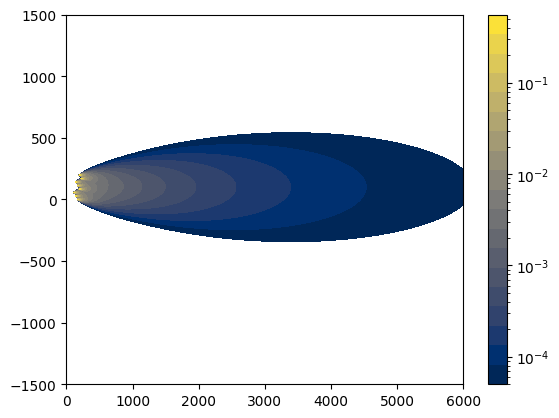

In [11]:
# Константы
SOURCE_EMISSION_RATE = 10  # Скорость выброса источника (кг/с)
WIND_SPEED = 3  # Скорость ветра (м/с)
WIND_DIRECTION = 135 # Направление ветра в градусах (Относительно оси X)
MIN_CONCENTRATION = 5*10e-6 # Минимальный порог концентрации
SOURCE_POSITIONS = [(100, 0, 0),   (180, 0, 0),
                    (100, 40, 0),  (180, 40, 0), (260, 40, 0), 
                                    (180, 80, 0), (260, 80, 0), 
                                                    (260, 120, 0)]  # Позиция источника (x0, y0, z0)

# Параметры сетки
DOMAIN_SIZE_X = 6000  # Размер области по x (м)
DOMAIN_SIZE_Y = 1500  # Размер области по y (м)
NUM_POINTS = 2000  # Количество точек для построения

# Создание модели
plume_model = StationaryGaussianPlumeModel(
    domain_size_x        = DOMAIN_SIZE_X,
    domain_size_y        = DOMAIN_SIZE_Y,
    num_points           = NUM_POINTS,
    source_emission_rate = SOURCE_EMISSION_RATE,
    wind_speed           = WIND_SPEED,
    wind_direction       = WIND_DIRECTION,
    source_positions     = SOURCE_POSITIONS
)

# Расчет концентрации
concentration = plume_model.calculate_concentration(1)

# Отрисовка графика
plt = plume_model.plot(concentration, MIN_CONCENTRATION)
plt.show()

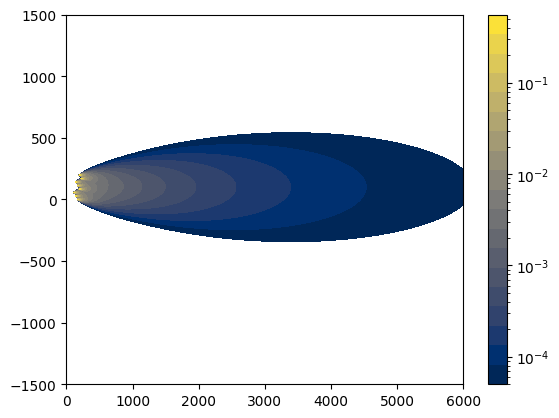

In [ ]:
# Константы
SOURCE_EMISSION_RATE = 10  # Скорость выброса источника (кг/с)
WIND_SPEED = 3  # Скорость ветра (м/с)
WIND_DIRECTION = 135 # Направление ветра в градусах (Относительно оси X)
MIN_CONCENTRATION = 5*10e-6 # Минимальный порог концентрации
SOURCE_POSITIONS = [(100, 0, 0),   (180, 0, 0),
                    (100, 40, 0),  (180, 40, 0), (260, 40, 0), 
                                    (180, 80, 0), (260, 80, 0), 
                                                    (260, 120, 0)]  # Позиция источника (x0, y0, z0)

# Параметры сетки
DOMAIN_SIZE_X = 6000  # Размер области по x (м)
DOMAIN_SIZE_Y = 1500  # Размер области по y (м)
NUM_POINTS = 2000  # Количество точек для построения

# Создание модели
plume_model = StationaryGaussianPlumeModel(
    domain_size_x        = DOMAIN_SIZE_X,
    domain_size_y        = DOMAIN_SIZE_Y,
    num_points           = NUM_POINTS,
    source_emission_rate = SOURCE_EMISSION_RATE,
    wind_speed           = WIND_SPEED,
    wind_direction       = WIND_DIRECTION,
    source_positions     = SOURCE_POSITIONS
)

# Расчет концентрации
concentration = plume_model.calculate_concentration2(1)

# Отрисовка графика
plt = plume_model.plot(concentration, MIN_CONCENTRATION)
plt.show()

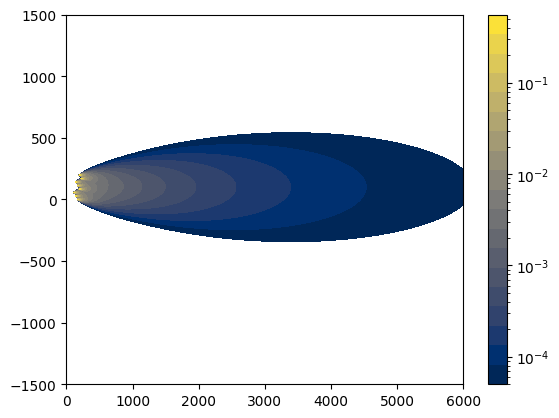

In [10]:
# Константы
SOURCE_EMISSION_RATE = 10  # Скорость выброса источника (кг/с)
WIND_SPEED = 3  # Скорость ветра (м/с)
WIND_DIRECTION = 135 # Направление ветра в градусах (Относительно оси X)
MIN_CONCENTRATION = 5*10e-6 # Минимальный порог концентрации
SOURCE_POSITIONS = [(100, 0, 0),   (180, 0, 0),
                    (100, 40, 0),  (180, 40, 0), (260, 40, 0), 
                                    (180, 80, 0), (260, 80, 0), 
                                                    (260, 120, 0)]  # Позиция источника (x0, y0, z0)

# Параметры сетки
DOMAIN_SIZE_X = 6000  # Размер области по x (м)
DOMAIN_SIZE_Y = 1500  # Размер области по y (м)
NUM_POINTS = 2000  # Количество точек для построения

# Создание модели
plume_model = StationaryGaussianPlumeModel(
    domain_size_x        = DOMAIN_SIZE_X,
    domain_size_y        = DOMAIN_SIZE_Y,
    num_points           = NUM_POINTS,
    source_emission_rate = SOURCE_EMISSION_RATE,
    wind_speed           = WIND_SPEED,
    wind_direction       = WIND_DIRECTION,
    source_positions     = SOURCE_POSITIONS
)

# Расчет концентрации
concentration = plume_model.calculate_concentration3(1)

# Отрисовка графика
plt = plume_model.plot(concentration, MIN_CONCENTRATION)
plt.show()